## Load

---

Load data describes electricity demand within a bidding zone or control area.

### Typical units

- Load: `MW`

### Typical applications

- Load forecasting
- Demand analysis
- Electricity price forecasting
- Forecast error analysis

---

# Config

---

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("ggplot")

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Settings

---

In [31]:
# Location
country_capital = "Madrid"
country_code = "ES"

# Period
tz = f"Europe/{country_capital}"

now = pd.Timestamp.now(tz=tz)
today = now.normalize()

yesterday = today - pd.Timedelta(days=1)
last_week = today - pd.Timedelta(days=7)
last_month = today - pd.DateOffset(months=1)

tomorrow = today + pd.Timedelta(days=1)
day_after_tomorrow = today + pd.Timedelta(days=2)
next_week = today + pd.Timedelta(days=7)
next_month = today + pd.DateOffset(months=1)

# EDA
---

###################################################################################
# .query_load
(country_code, start=start, end=end) -> pd.DataFrame

* Actual total load, defined as equal to the sum of power generated by plants on both TSO/DSO networks, from which is deduced: the balance (export-import) of exchanges on interconnections between neighbouring bidding zones and the power absorbed by energy storage resources.

In [7]:
load = entsoe_client.query_load(
    country_code=country_code,
    start=last_week,
    end=now)

In [8]:
now

Timestamp('2026-08-27 19:48:10.925672+0200', tz='Europe/Madrid')

In [9]:
load.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 750 entries, 2026-08-20 00:00:00+02:00 to 2026-08-27 19:15:00+02:00
Freq: 15min
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Actual Load  750 non-null    float64
dtypes: float64(1)
memory usage: 11.7 KB


In [10]:
load.head()

,Actual Load
2026-08-20 00:00:00+02:00,30588.0
2026-08-20 00:15:00+02:00,30348.0
2026-08-20 00:30:00+02:00,29944.0
2026-08-20 00:45:00+02:00,29304.0
2026-08-20 01:00:00+02:00,28848.0


In [11]:
load.tail()

,Actual Load
2026-08-27 18:15:00+02:00,30948.0
2026-08-27 18:30:00+02:00,31144.0
2026-08-27 18:45:00+02:00,31344.0
2026-08-27 19:00:00+02:00,31200.0
2026-08-27 19:15:00+02:00,31312.0


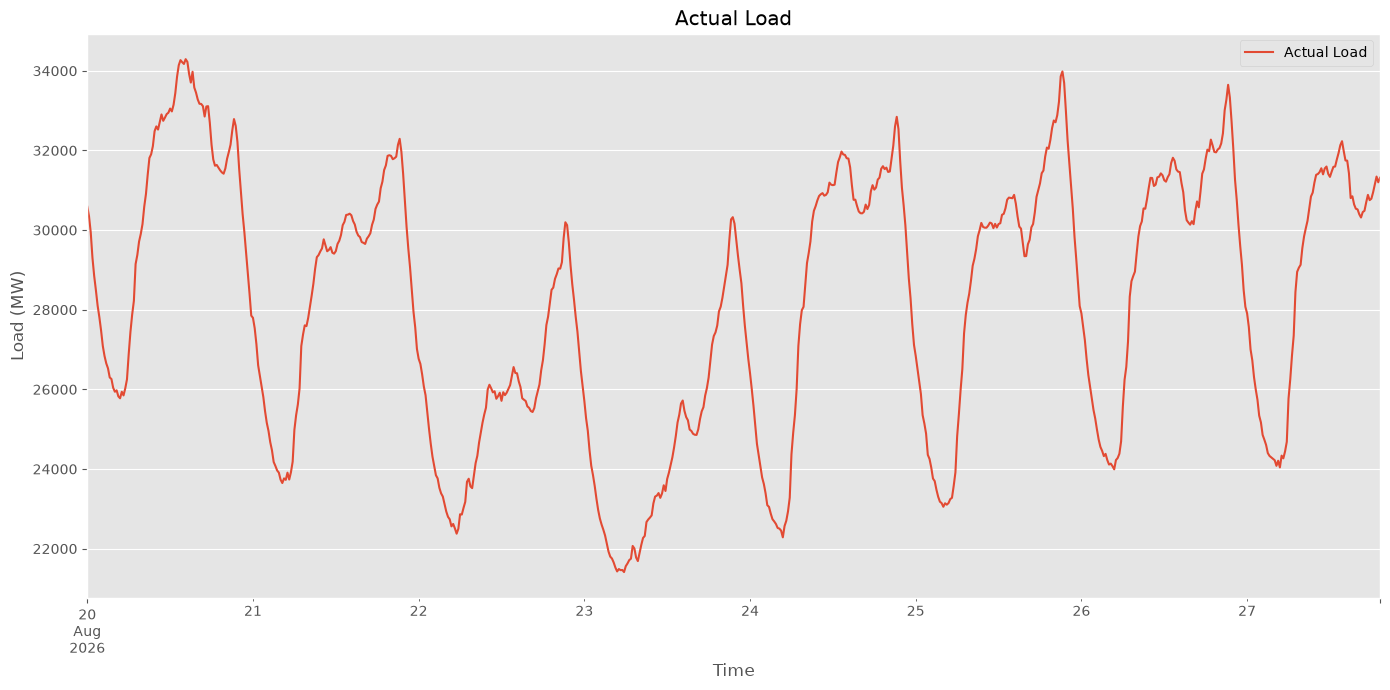

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))

load.plot(ax=ax)

ax.set_title("Actual Load")
ax.set_xlabel("Time")
ax.set_ylabel("Load (MW)")

fig.tight_layout()
plt.show()

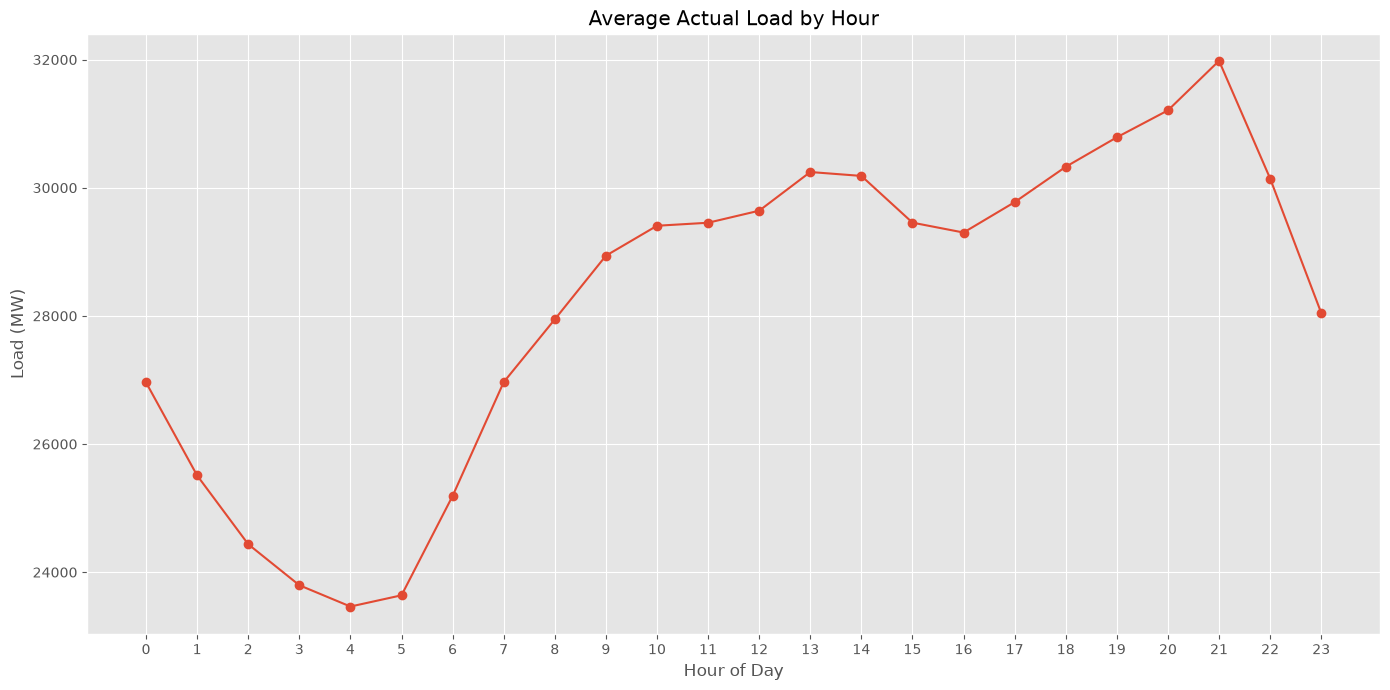

In [19]:
fig, ax = plt.subplots(figsize=(14, 7))

load.groupby(load.index.hour).mean().plot(
    ax=ax,
    marker="o"
)

ax.set_title("Average Actual Load by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Load (MW)")
ax.set_xticks(range(24))

fig.tight_layout()
plt.show()

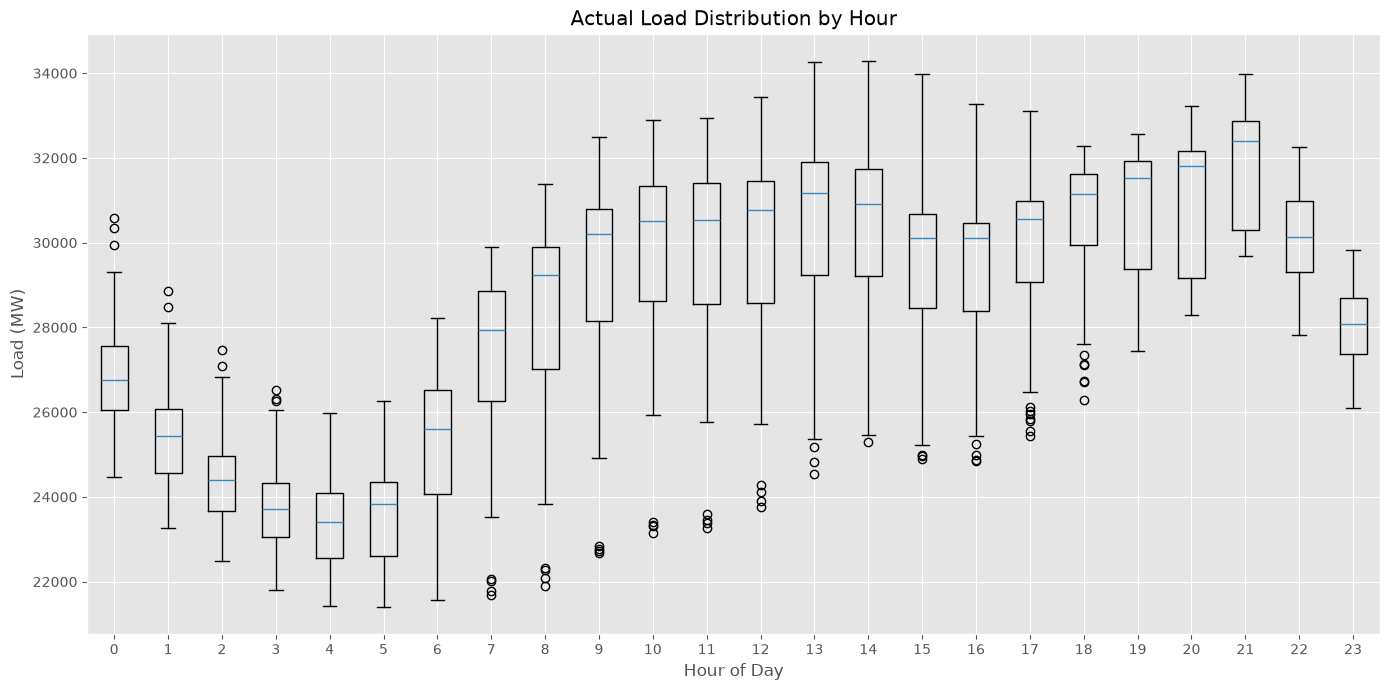

In [20]:
prices_by_hour = [
    load['Actual Load'][load['Actual Load'].index.hour == hour].values
    for hour in range(24)
]

fig, ax = plt.subplots(figsize=(14, 7))

ax.boxplot(prices_by_hour)

ax.set_title("Actual Load Distribution by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Load (MW)")
ax.set_xticks(range(1, 25), range(24))

fig.tight_layout()
plt.show()

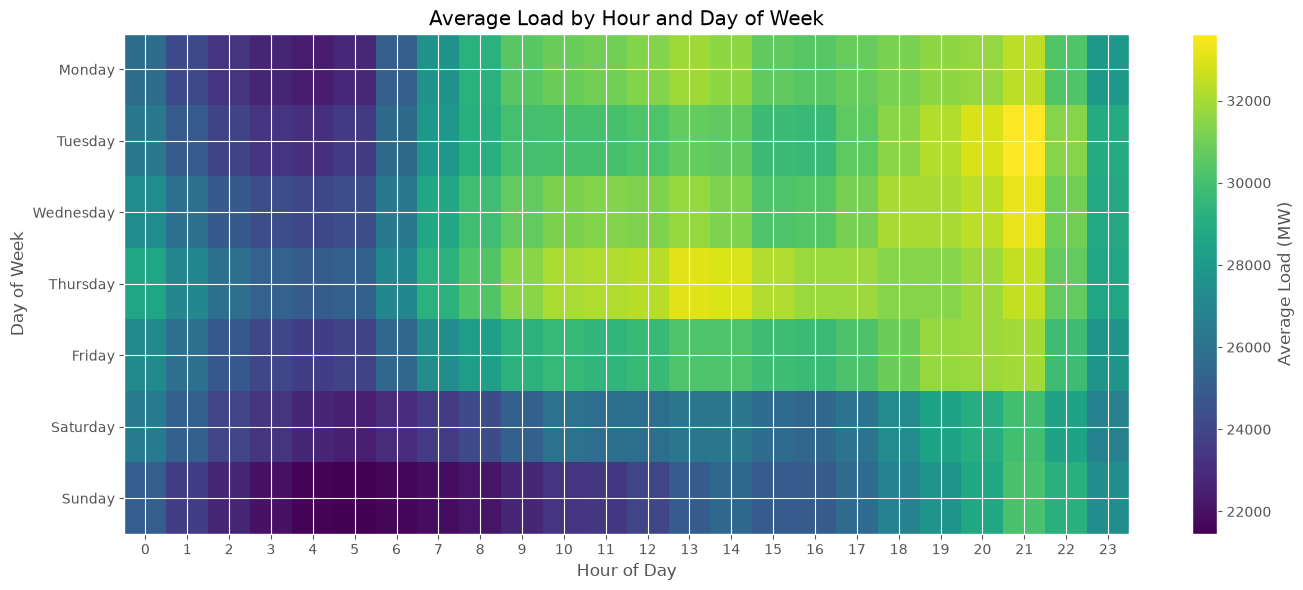

In [24]:
prices = load['Actual Load'].copy()
prices.index = pd.to_datetime(prices.index)

# Average price for each hour and day of week
heatmap_data = (
    prices
    .groupby([
        prices.index.day_name(),
        prices.index.hour
    ])
    .mean()
    .unstack()
)

# Put days in the correct order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

heatmap_data = heatmap_data.reindex(day_order)


fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest"
)

# Axis labels
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_title("Average Load by Hour and Day of Week")

# Ticks
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))

ax.set_yticks(range(7))
ax.set_yticklabels(day_order)

# Colorbar
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Average Load (MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_load_forecast
(country_code, start=start, end=end) -> pd.DataFrame

* Day-ahead forecast, defined as equal to the sum of power generated by plants on both TSO/DSO networks, from which is deduced: the balance (export-import) of exchanges on interconnections between neighbouring bidding zones and the power absorbed by energy storage resources.

In [37]:
load_fcst = entsoe_client.query_load_forecast(
    country_code=country_code,
    start=last_week,
    end=day_after_tomorrow)

In [38]:
load_fcst.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 864 entries, 2026-08-20 00:00:00+02:00 to 2026-08-28 23:45:00+02:00
Freq: 15min
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Forecasted Load  864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB


In [39]:
load_fcst.head()

,Forecasted Load
2026-08-20 00:00:00+02:00,30323.0
2026-08-20 00:15:00+02:00,29764.0
2026-08-20 00:30:00+02:00,29253.0
2026-08-20 00:45:00+02:00,28787.0
2026-08-20 01:00:00+02:00,28312.0


In [40]:
load_fcst.tail()

,Forecasted Load
2026-08-28 22:45:00+02:00,28707.0
2026-08-28 23:00:00+02:00,28092.0
2026-08-28 23:15:00+02:00,27638.0
2026-08-28 23:30:00+02:00,27242.0
2026-08-28 23:45:00+02:00,26890.0


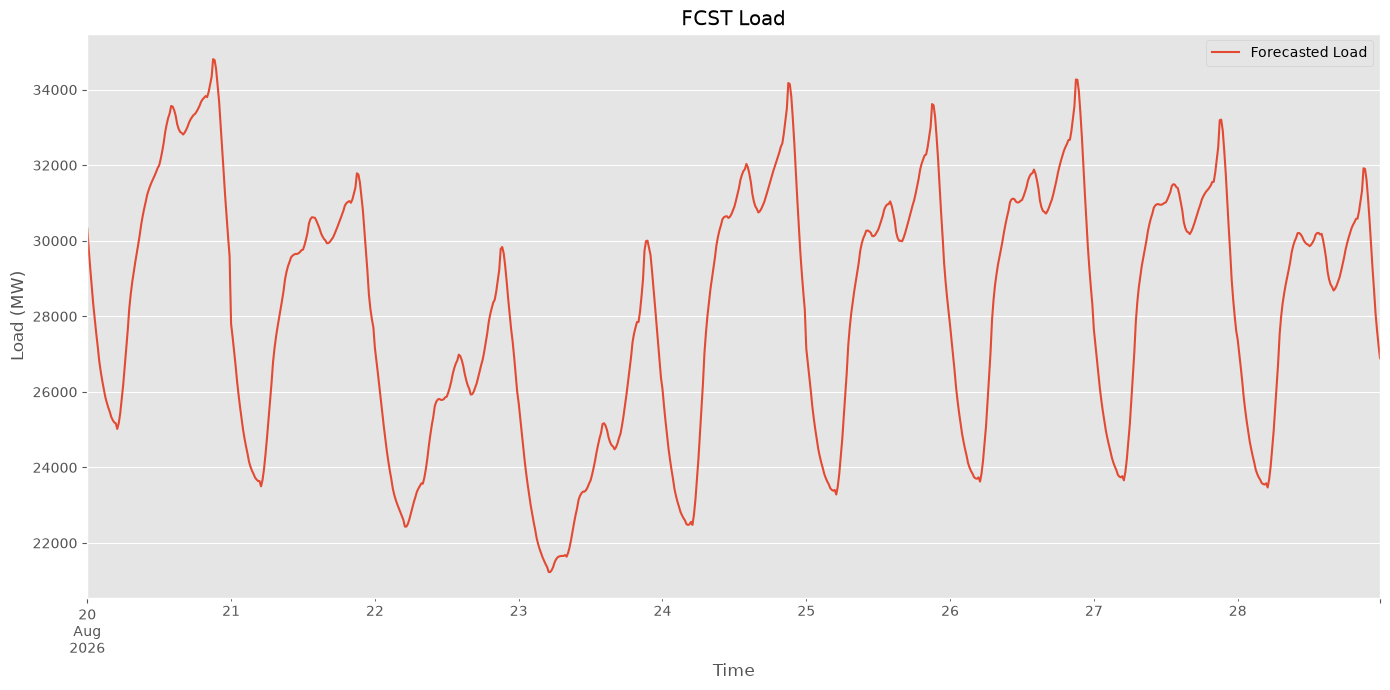

In [41]:
fig, ax = plt.subplots(figsize=(14, 7))

load_fcst.plot(ax=ax)

ax.set_title("FCST Load")
ax.set_xlabel("Time")
ax.set_ylabel("Load (MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_load_and_forecast
(country_code, start=start, end=end) -> pd.DataFrame

In [45]:
load_and_fcst = entsoe_client.query_load_and_forecast(
    country_code=country_code,
    start=last_week,
    end=now)

In [46]:
load_and_fcst.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 752 entries, 2026-08-20 00:00:00+02:00 to 2026-08-27 19:45:00+02:00
Freq: 15min
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Forecasted Load  752 non-null    float64
 1   Actual Load      751 non-null    float64
dtypes: float64(2)
memory usage: 33.8 KB


In [47]:
load_and_fcst.head()

,Forecasted Load,Actual Load
2026-08-20 00:00:00+02:00,30323.0,30588.0
2026-08-20 00:15:00+02:00,29764.0,30348.0
2026-08-20 00:30:00+02:00,29253.0,29944.0
2026-08-20 00:45:00+02:00,28787.0,29304.0
2026-08-20 01:00:00+02:00,28312.0,28848.0


<Axes: >

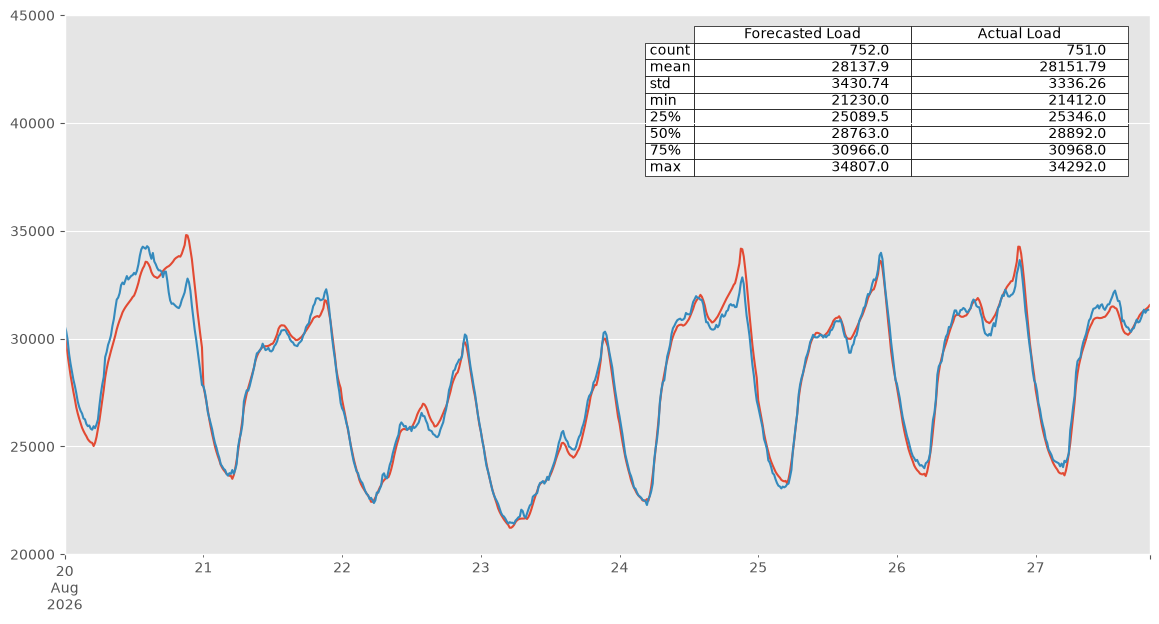

In [57]:
from pandas.plotting import table

fig, ax = plt.subplots(figsize=(14, 7))

table(ax, np.round(load_and_fcst.describe(), 2), loc="upper right", colWidths=[0.2, 0.2, 0.2])
load_and_fcst.plot(ax=ax, ylim=(20000, 45000), legend=None)

In [53]:
pivot = pd.pivot_table(
    load_and_fcst,
    values=["Actual Load", "Forecasted Load"],
    index=load_and_fcst.index.date,
    aggfunc="sum"
)

pivot["Delta"] = pivot["Actual Load"] - pivot["Forecasted Load"]

print(pivot.round(2))

            Actual Load  Forecasted Load    Delta
2026-08-20    2949352.0        2945083.0   4269.0
2026-08-21    2732972.0        2730587.0   2385.0
2026-08-22    2471740.0        2473334.0  -1594.0
2026-08-23    2368288.0        2348635.0  19653.0
2026-08-24    2751080.0        2774580.0 -23500.0
2026-08-25    2762260.0        2768155.0  -5895.0
2026-08-26    2819676.0        2824065.0  -4389.0
2026-08-27    2286624.0        2295260.0  -8636.0


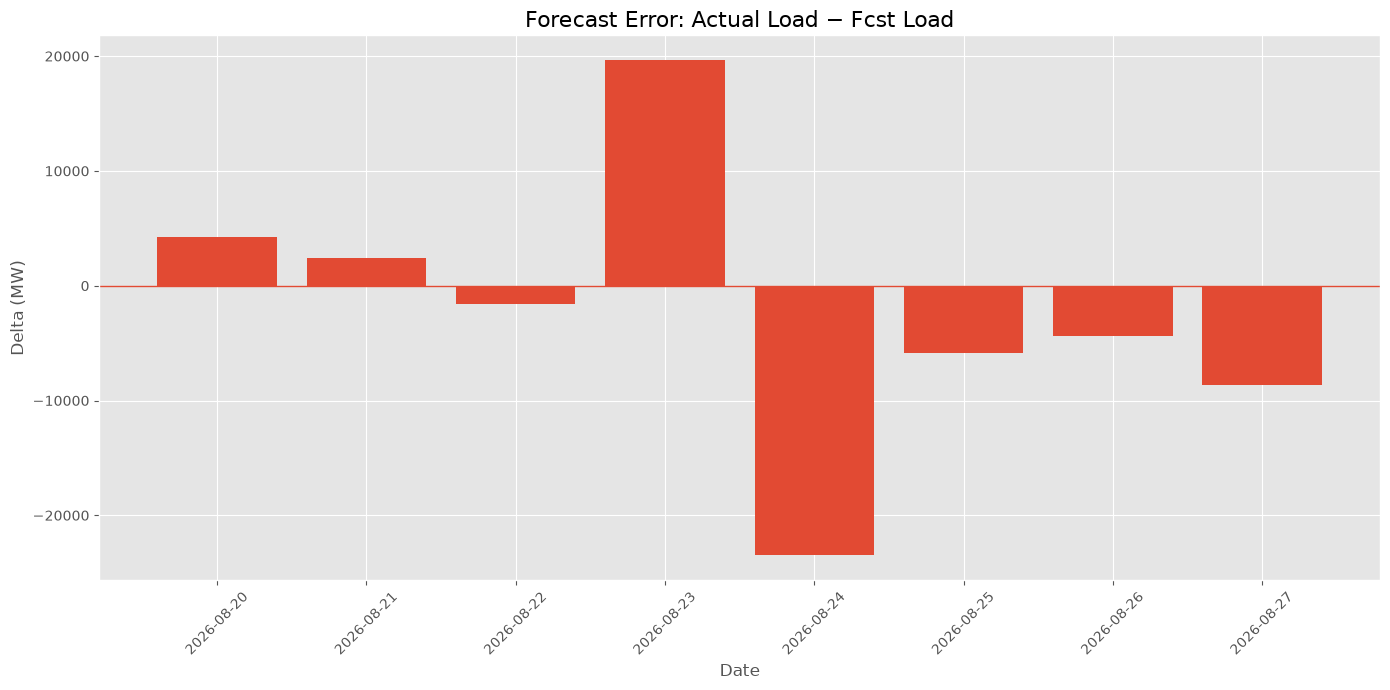

In [55]:
fig, ax = plt.subplots(figsize=(14, 7))

plt.bar(
    pivot.index,
    pivot["Delta"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Forecast Error: Actual Load − Fcst Load", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Delta (MW)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()